[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benjamalegni/ML-luka/blob/main/02-deep-learning/01-tpe-eurosat-satelital/TPE_Redes_Neuronales (3).ipynb)


# 1. Exploración y preparación de los datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
from pathlib import Path

# Define la ruta a la carpeta EuroSAT_TP en mi Google Drive
drive_path = Path('/content/drive/MyDrive/EuroSAT_TP')

if not drive_path.exists():
    print(f"La carpeta {drive_path} no existe. Crea esta carpeta en tu Google Drive o verifica la ruta.")
else:
    print(f"{drive_path}:")
    for folder in os.listdir(drive_path):
        print("- ", folder)
        for item in os.listdir(drive_path / folder):
            print("  - ", item)

Streaming output truncated to the last 5000 lines.
  -  River_302.jpg
  -  River_2435.jpg
  -  River_2447.jpg
  -  River_192.jpg
  -  River_1968.jpg
  -  River_1463.jpg
  -  River_2186.jpg
  -  River_1778.jpg
  -  River_501.jpg
  -  River_1336.jpg
  -  River_1762.jpg
  -  River_655.jpg
  -  River_549.jpg
  -  River_1372.jpg
  -  River_1380.jpg
  -  River_669.jpg
  -  River_1815.jpg
  -  River_1099.jpg
  -  River_42.jpg
  -  River_2148.jpg
  -  River_1804.jpg
  -  River_1776.jpg
  -  River_1742.jpg
  -  River_1468.jpg
  -  River_703.jpg
  -  River_797.jpg
  -  River_493.jpg
  -  River_264.jpg
  -  River_2056.jpg
  -  River_1270.jpg
  -  River_46.jpg
  -  River_2227.jpg
  -  River_1078.jpg
  -  River_391.jpg
  -  River_780.jpg
  -  River_1638.jpg
  -  River_1281.jpg
  -  River_467.jpg
  -  River_2282.jpg
  -  River_1512.jpg
  -  River_133.jpg
  -  River_307.jpg
  -  River_1261.jpg
  -  River_1944.jpg
  -  River_521.jpg
  -  River_902.jpg
  -  River_1117.jpg
  -  River_2047.jpg
  -  River

In [5]:
import shutil

# descargar la carpeta de drive localmente

origen_drive = Path('/content/drive/MyDrive/EuroSAT_TP')
destino_local = Path('/content/EuroSAT_TP_local')

if origen_drive.exists():
    if os.path.exists(destino_local):
        print(f"La carpeta de destino '{destino_local}' ya existe. Eliminándola para realizar una copia limpia...")
        shutil.rmtree(destino_local)

    print("Copiando la carpeta desde Google Drive al almacenamiento local de Colab...")
    shutil.copytree(str(origen_drive), destino_local)
    print(f"La carpeta se copió correctamente a: {destino_local}")
    print("Clases copiadas:", os.listdir(destino_local))
else:
    print(f"No se encontró la carpeta de origen en Google Drive: {origen_drive}. Asegúrate de tener el Drive montado.")

Copiando la carpeta desde Google Drive al almacenamiento local de Colab...
La carpeta se copió correctamente a: /content/EuroSAT_TP_local
Clases copiadas: ['SeaLake', 'HerbaceousVegetation', 'Forest', 'PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'Pasture', 'River', 'Highway']


Este dataset incluye imagenes a color de distintos tipos de terrenos.

Cada clase representa un tipo distinto de cobertura del suelo, lo que hace que el dataset sea ideal para tareas de clasificación de imágenes en teledetección.

### Conteo de imágenes por clase y visualización de la distribución

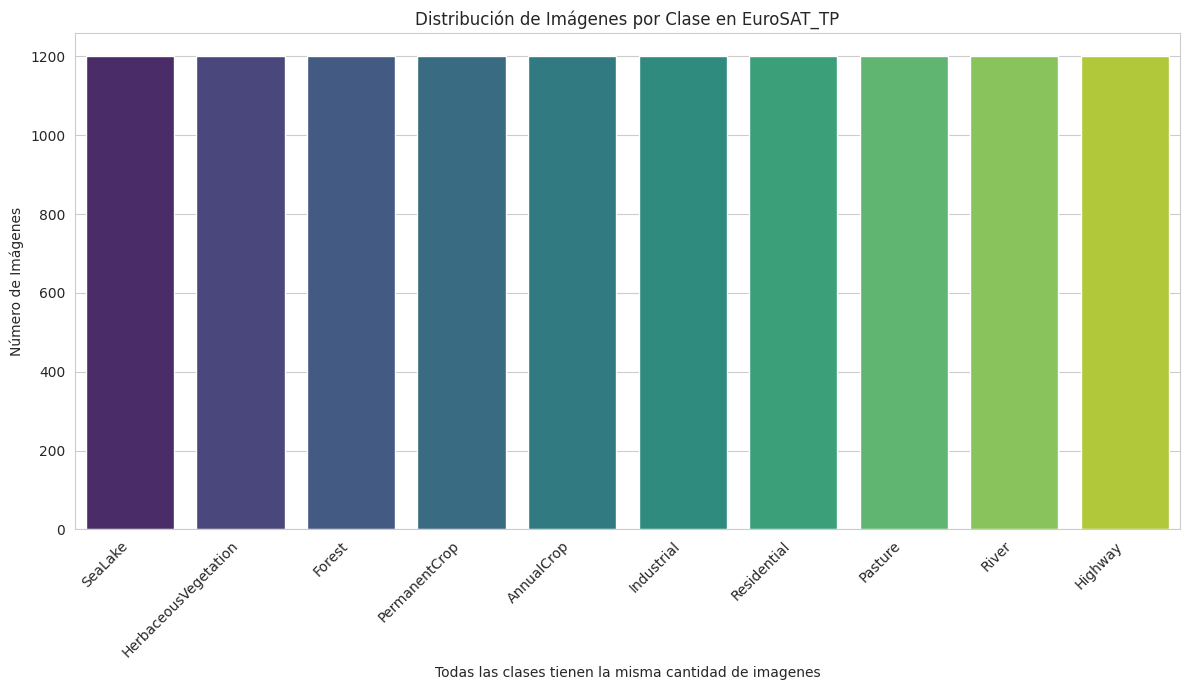

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import Counter

class_counts = Counter()
for folder in os.listdir(destino_local):
    folder_path = destino_local / folder
    if folder_path.is_dir():
        num_images = len([name for name in os.listdir(folder_path) if name.lower().endswith(('.', '.jpg', '.jpeg'))])
        class_counts[folder] = num_images

df_class_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_class_counts = df_class_counts.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis', hue='Class')
plt.title('Distribución de Imágenes por Clase en EuroSAT_TP')
plt.xlabel('Todas las clases tienen la misma cantidad de imagenes')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualización de imágenes de ejemplo por clase

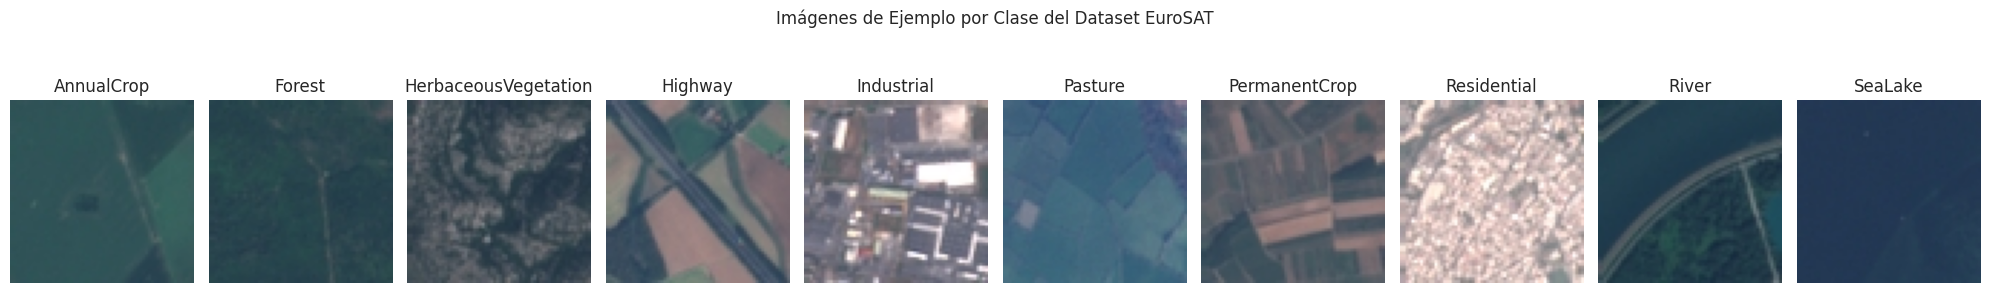

In [7]:
import random
from PIL import Image
import numpy as np

classes = [f.name for f in destino_local.iterdir() if f.is_dir()]
classes.sort()

# Crear una figura para mostrar una imagen de cada clase
fig, axes = plt.subplots(1, len(classes), figsize=(20, 3))

for i, class_name in enumerate(classes):
    class_path = destino_local / class_name

    # Obtener todas las imágenes en la clase
    images_in_class = [f for f in class_path.iterdir() if f.suffix.lower() in ('.png', '.jpg', '.jpeg')]

    if images_in_class:
        # Seleccionar una imagen aleatoria
        random_image_path = random.choice(images_in_class)
        img = Image.open(random_image_path)

        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off')
    else:
        axes[i].set_title(f'{class_name}\n(No images)')
        axes[i].axis('off')

plt.suptitle('Imágenes de Ejemplo por Clase del Dataset EuroSAT', y=1.05)
plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

# constantes para splitting
SPLIT_RATIO = 0.3
SEED = 42
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# 70% Train y 30% Temp (Val + Test)
raw_train_ds, temp_ds = tf.keras.utils.image_dataset_from_directory(
    destino_local,
    validation_split=SPLIT_RATIO,
    subset="both",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# guardo class_names ANTES de transformar los datasets
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print(f"Clases detectadas ({num_classes}): {class_names}")

# divido el 30% de test en 15% Val y 15% Test
temp_ds = temp_ds.cache()
val_size = int(len(temp_ds) * 0.5)
val_ds_raw = temp_ds.take(val_size)
test_ds_raw = temp_ds.skip(val_size)

# optimizaciones para GPU
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.prefetch(buffer_size=AUTOTUNE)


Found 12000 files belonging to 10 classes.
Using 8400 files for training.
Using 3600 files for validation.
Clases detectadas (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [9]:
# como en las imagenes satelitales el norte es arbitrario, puedo hacer rotaciones  en 90°, 180°, 270°, espejados horizontales y verticales porque conservan 100% el significado semántico

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

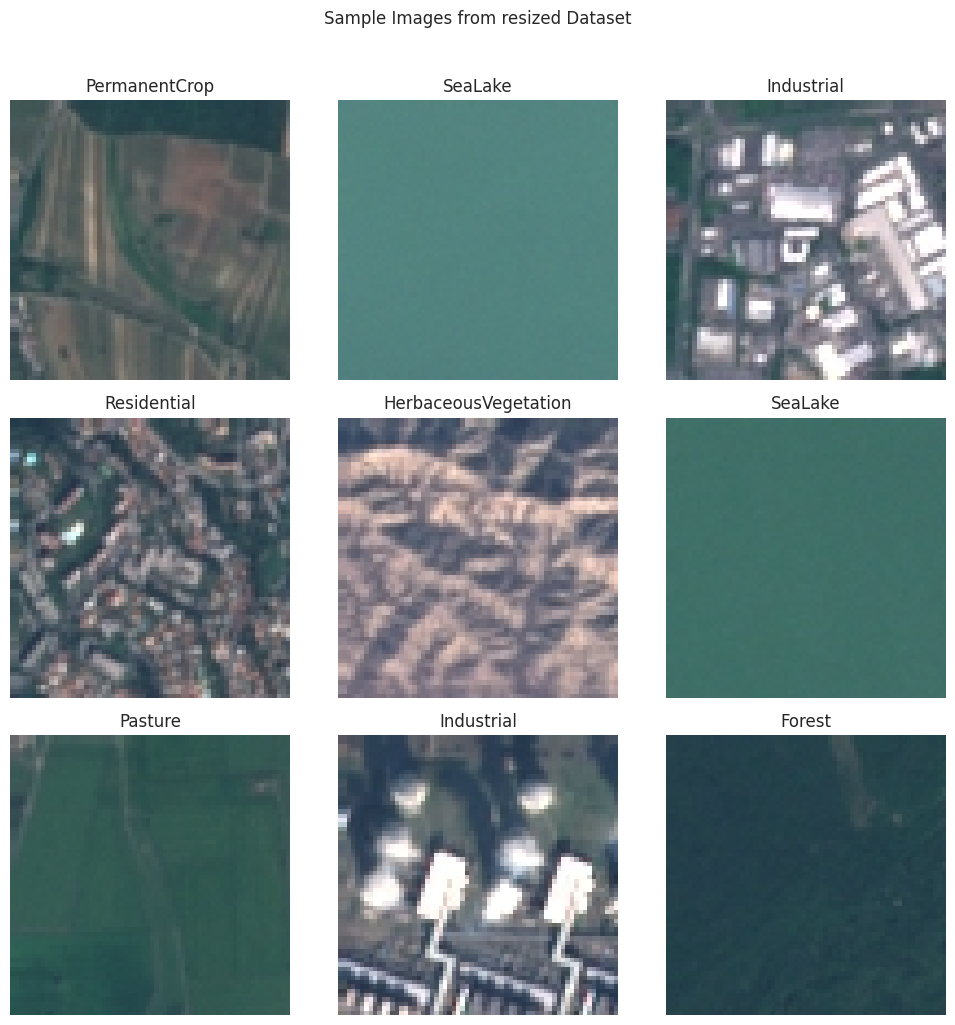

In [10]:
# Get class names from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle('Sample Images from resized Dataset', y=1.02)
plt.tight_layout()
plt.show()

# 2. Desarrollo de la red neuronal propia

Estare utilizando redes neuronales convolucionales (CNN) debido a que esta arquitectura aprovecha patrones locales y comparte pesos, esto la hace ideal para trabajar con imagenes.


Utilizaré Keras, que abstrae los detalles de implementación y permite escribir el modelo de forma independiente del backend (TensorFlow, JAX o PyTorch).

## Arquitectura propuesta 1

In [11]:
def build_baseline(n_classes=10):
    return tf.keras.Sequential([
        tf.keras.layers.Input((64, 64, 3)),
        tf.keras.layers.Rescaling(1./255),


        # input de 64x64 en RGB
        # la resolucion espacial disminuye en cada bloque, y aumenta la profundidad
        # en todos los bloques (menos en la cabeza) aplico un batch normalization antes de la relu - para estandarizar los datos de un bloque a otro
        # los 3 bloques siguen este flujo:
        # - Conv2d -> batchNormalization -> relu -> maxPooling2D -> spatialDropout

        # bloque 1 — textura y bordes (32x32)
        # busco capturar solo caracteristicas simples
        tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.20),

        # bloque 2 — patrones de textura (16x16)
        tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.25),

        # bloque 3 — semántica de la clase (8x8)
        tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.30),

        # cabeza
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])

La arquitectura propuesta consta de 3 capas + la cabeza.

El flujo es Conv2d -> batchNormalization -> relu -> maxPooling2D -> spatialDropout.
Los valores en spatialDropout2D van aumentando para evitar el overfitting.

## Cabeza
Las transformaciones realizadas en la cabeza son:
- globalAveragePooling2D, donde calcula un promedio de sus valores de entrada
- luego se pasa por una layer densa (el evaluador),
- un dropout que apaga el 40% de las neuronas de la red neuronal densa
- una ultima capa de salida dense_1 que tiene el mismo numero de neuronas que las clases del EuroSat.

In [12]:
build_baseline(n_classes=num_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 32, 32, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,722 (436.41 KB)

 Trainable params: 111,274 (434.66 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
cnn = build_baseline(n_classes=10)

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# CNN training
# history_cnn es el historial del entrenamiento, no la red en si
# probe anteriormente con 5 epocas, lo que resulto en metricas

epochs = 10
history_cnn = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.3754 - loss: 1.6952 - val_accuracy: 0.1574 - val_loss: 2.5193
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4868 - loss: 1.4024 - val_accuracy: 0.3979 - val_loss: 1.5970
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5352 - loss: 1.2759 - val_accuracy: 0.3382 - val_loss: 2.2007
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5688 - loss: 1.1971 - val_accuracy: 0.5234 - val_loss: 1.2264
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5787 - loss: 1.1591 - val_accuracy: 0.7003 - val_loss: 0.8733
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6006 - loss: 1.1076 - val_accuracy: 0.5642 - val_loss: 1.1550
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6118 - loss: 1.0718 - val_accuracy: 0.6713 - val_loss: 0.9282
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6251 - loss: 1.0405 - val_accurac

In [15]:
test_loss, test_acc = cnn.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.2f}")
print(f"Test loss: {test_loss:.2f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6659 - loss: 0.9280
Test accuracy: 0.67
Test loss: 0.93


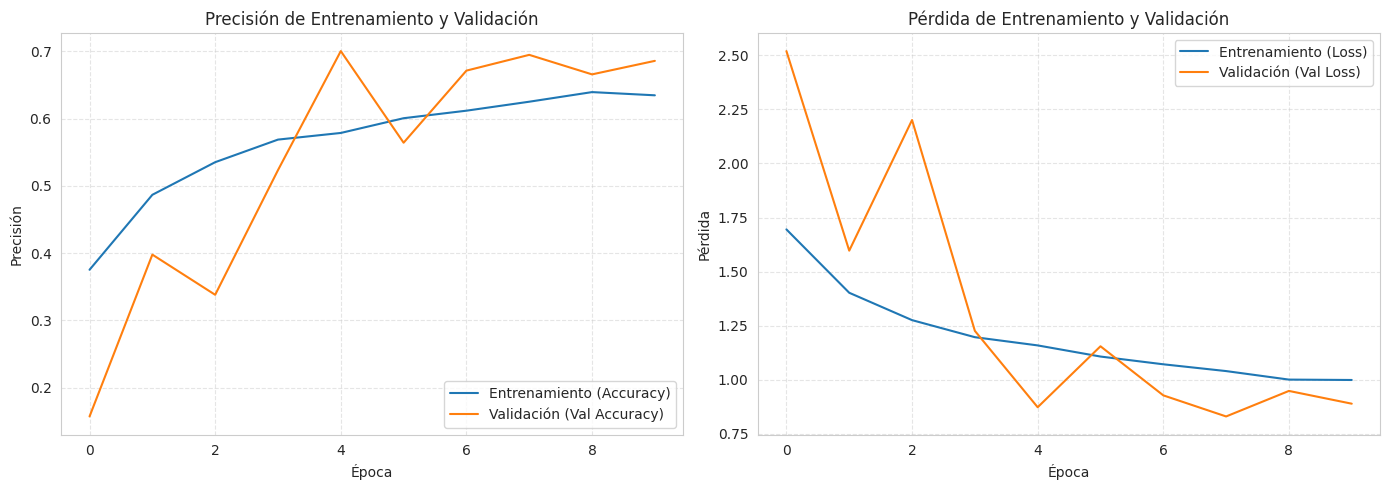

In [16]:
# Graficar la pérdida y precisión del entrenamiento y validación
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Accuracy)')
plt.plot(epochs_range, val_acc, label='Validación (Val Accuracy)')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Loss)')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Arquitectura propuesta 2

### Justificación del Diseño: Transición a Conexiones Residuales (Skip Connections)

Al analizar las curvas de aprendizaje de nuestra **CNN Baseline (Arquitectura 1)**, observamos varias limitaciones críticas:
1. **Estancamiento del Aprendizaje:** La precisión de validación se estanca en torno al **73%**, lo que sugiere una capacidad de representación limitada.
2. **Inestabilidad y Oscilaciones:** Existen fuertes oscilaciones en la pérdida y precisión de validación, un síntoma de que el optimizador está dando pasos demasiado grandes en regiones complejas de la función de pérdida.
3. **Degradación del Gradiente:** A medida que intentamos diseñar redes más profundas para capturar patrones más abstractos (necesarios para distinguir texturas complejas de satélite), los gradientes disminuyen al propagarse hacia atrás, dificultando el entrenamiento de las primeras capas.

#### ¿Por qué usar Skip Connections (ResNet)?
Para resolver estos problemas, migramos a una arquitectura basada en **bloques residuales**:
* **Propagación del Gradiente:** Las conexiones residuales o *skip connections* permiten que el gradiente fluya directamente a través del atajo (*shortcut*) sin verse atenuado por las multiplicaciones sucesivas de las capas convolucionales. Esto evita la degradación del gradiente y permite entrenar redes más profundas con facilidad.
* **Aprendizaje Residual:** En lugar de forzar a las capas a aprender el mapeo completo deseado $H(x)$, la red solo necesita aprender la función residual $F(x) = H(x) - x$, facilitando la convergencia.
* **Regularización Adaptativa y Robustez:** Acompañamos esta mejora arquitectónica introduciendo **Data Augmentation** activo para evitar el sobreajuste ante rotaciones/zooms, y callbacks avanzados como **ReduceLROnPlateau** para reducir de manera dinámica la tasa de aprendizaje al detectar un estancamiento en la pérdida de validación.

In [17]:
def residual_block(x, filters):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Ajuste de dimensiones del shortcut si cambian los canales
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.add([x, shortcut])
    x = tf.keras.layers.ReLU()(x)
    return x

def build_improved_cnn(input_shape=(64, 64, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    x = data_augmentation(x)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = residual_block(x, 32)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = residual_block(x, 64)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = residual_block(x, 128)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="CNN_ResNet_Custom")

In [18]:
improved_cnn = build_improved_cnn(num_classes=len(class_names))
build_improved_cnn(input_shape=(64, 64, 3), num_classes=10).summary()

Model: "CNN_ResNet_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 64, 64, 3) │          0 │ input_layer_4[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 64, 3) │          0 │ rescaling_3[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │        864 │ sequential[1][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │      9,216 │ re_lu_7[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │      9,216 │ re_lu_8[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 64, 64,    │          0 │ add_3[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ re_lu_9[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     18,432 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 309,994 (1.18 MB)

 Trainable params: 308,650 (1.18 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [19]:
from tensorflow.keras import callbacks

custom_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Compilación
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 25

history_improved = improved_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=custom_callbacks,
    verbose=1
)

Epoch 1/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.5842 - loss: 1.1688 - val_accuracy: 0.1166 - val_loss: 4.5196 - learning_rate: 0.0010
Epoch 2/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.6951 - loss: 0.8584 - val_accuracy: 0.5017 - val_loss: 1.2714 - learning_rate: 0.0010
Epoch 3/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7354 - loss: 0.7428 - val_accuracy: 0.7316 - val_loss: 0.7506 - learning_rate: 0.0010
Epoch 4/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7664 - loss: 0.6704 - val_accuracy: 0.2305 - val_loss: 7.7039 - learning_rate: 0.0010
Epoch 5/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7826 - loss: 0.6208 - val_accuracy: 0.3560 - val_loss: 4.5862 - learning_rate: 0.0010
Epoch 6/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7984 - loss: 0.5720
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8049 - los

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9015 - loss: 0.3003

Exactitud en Test (CNN Mejorada con Residuales): 90.15%
Pérdida en Test: 0.3003


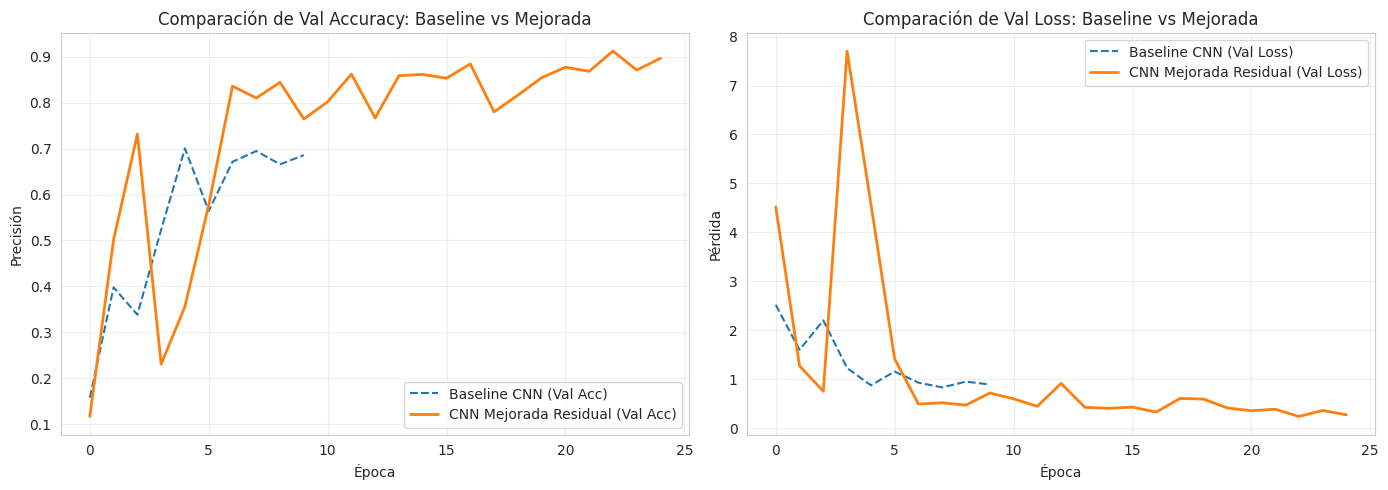

In [20]:
test_loss_imp, test_acc_imp = improved_cnn.evaluate(test_ds)
print(f"\nExactitud en Test (CNN Mejorada con Residuales): {test_acc_imp * 100:.2f}%")
print(f"Pérdida en Test: {test_loss_imp:.4f}")

# Gráfico comparativo de curvas de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['val_accuracy'], '--', label='Baseline CNN (Val Acc)')
plt.plot(history_improved.history['val_accuracy'], '-', label='CNN Mejorada Residual (Val Acc)', linewidth=2)
plt.title('Comparación de Val Accuracy: Baseline vs Mejorada')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['val_loss'], '--', label='Baseline CNN (Val Loss)')
plt.plot(history_improved.history['val_loss'], '-', label='CNN Mejorada Residual (Val Loss)', linewidth=2)
plt.title('Comparación de Val Loss: Baseline vs Mejorada')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# transfer learning
Solucion a partir de una arquitectura pre entrenada

Utilizare el modelo pre entrenado ResNet-50, el cual es una CNN de 50 capas de profundidad creada por Microsoft Research en 2015

Entrenado con mas de un millon de imagenes de la base de datos de ImageNet y puede clasificar imagenes en 1000 categorias diferentes.

### Implementación de Transfer Learning con ResNet-50

Construiremos un modelo donde la base de ResNet-50 esté congelada (no se entrenarán sus pesos iniciales de ImageNet), y agregare una cabeza de clasificación personalizada para EuroSAT.

In [21]:
resnet_base = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)

# congelo los pesos de base para no perder su entrenamiento con ImageNet
resnet_base.trainable = False

# nuevo modelo de transfer learning
model_tl = tf.keras.Sequential([
    tf.keras.layers.Input((64, 64, 3)),
    # 1. uso el data augmentation que defini mas arriba
    data_augmentation,
    # 2. Reescalar a 128x128 para que ResNet-50 no destruya la resolución espacial
    tf.keras.layers.Resizing(128, 128),
    # 3. Preprocesamiento de ResNet50
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),



    # Base convolucional de ResNet50
    resnet_base,

    # Nueva cabeza clasificadora
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_tl.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
# Compilar el modelo con Transfer Learning (Fase 1: Feature Extraction)
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FASE1 = 5

# Entrenar por 5 épocas monitoreando sobre val_ds
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1,
    verbose=1
)

# Evaluar rendimiento intermedio de la fase 1 en Test para medir la mejora posterior
loss_fase1, acc_fase1 = model_tl.evaluate(test_ds, verbose=0)
print(f"\nExactitud en Test tras Fase 1 (Feature Extraction): {acc_fase1 * 100:.2f}%")

Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.8049 - loss: 0.7042 - val_accuracy: 0.8979 - val_loss: 0.3249
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8887 - loss: 0.3531 - val_accuracy: 0.9040 - val_loss: 0.3078
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9102 - loss: 0.2727 - val_accuracy: 0.9096 - val_loss: 0.3114
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9265 - loss: 0.2217 - val_accuracy: 0.8990 - val_loss: 0.3340
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9338 - loss: 0.1972 - val_accuracy: 0.9102 - val_loss: 0.3314

Exactitud en Test tras Fase 1 (Feature Extraction): 90.82%


In [23]:
# transfer learning fase 2: Fine-Tuning (Descongelar las capas superiores de ResNet-50)

resnet_base.trainable = True

# Descongelar únicamente las últimas 25 capas convolucionales
for layer in resnet_base.layers[:-25]:
    layer.trainable = False

# Recompilar con un Learning Rate mucho más bajo para no destruir los pesos previos
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar por 6 épocas adicionales con EarlyStopping
history_tl_fine = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.8515 - loss: 0.4966 - val_accuracy: 0.8856 - val_loss: 0.4126
Epoch 2/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9256 - loss: 0.2266 - val_accuracy: 0.8968 - val_loss: 0.3652
Epoch 3/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9525 - loss: 0.1513 - val_accuracy: 0.9051 - val_loss: 0.3451
Epoch 4/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9700 - loss: 0.1062 - val_accuracy: 0.9079 - val_loss: 0.3379
Epoch 5/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9799 - loss: 0.0775 - val_accuracy: 0.9096 - val_loss: 0.3347
Epoch 6/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9861 - loss: 0.0588 - val_accuracy: 0.9113 - val_loss: 0.3346
Epoch 7/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9898 - loss: 0.0476 - val_accuracy: 0.9129 - val_loss: 0.3366
Epoch 8/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9921 - loss: 0.0363 - val_accuracy: 

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9159 - loss: 0.3118

Exactitud Final en Test (ResNet-50 Fine-Tuned): 91.59%
Pérdida Final en Test: 0.3118
Mejora por Fine-Tuning: +0.77%


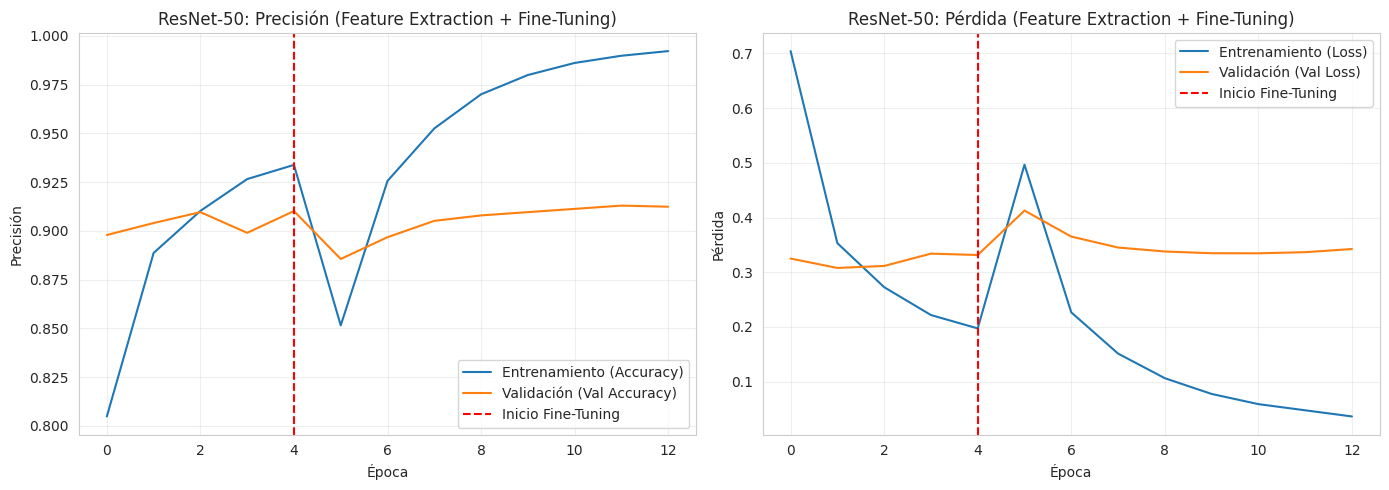

In [24]:
# 1. Evaluación final en Test tras Fine-Tuning
test_loss_tl, test_acc_tl = model_tl.evaluate(test_ds)
print(f"\n==================================================")
print(f"Exactitud Final en Test (ResNet-50 Fine-Tuned): {test_acc_tl * 100:.2f}%")
print(f"Pérdida Final en Test: {test_loss_tl:.4f}")
print(f"Mejora por Fine-Tuning: +{(test_acc_tl - acc_fase1) * 100:.2f}%")
print(f"==================================================")

# 2. Concatenar métricas de Fase 1 y Fase 2
acc = history_tl.history['accuracy'] + history_tl_fine.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_tl_fine.history['val_accuracy']
loss = history_tl.history['loss'] + history_tl_fine.history['loss']
val_loss = history_tl.history['val_loss'] + history_tl_fine.history['val_loss']

plt.figure(figsize=(14, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento (Accuracy)')
plt.plot(val_acc, label='Validación (Val Accuracy)')
plt.axvline(x=EPOCHS_FASE1 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50: Precisión (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento (Loss)')
plt.plot(val_loss, label='Validación (Val Loss)')
plt.axvline(x=EPOCHS_FASE1 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50: Pérdida (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Implementación de Transfer Learning con ResNet-50 (Versión Mejorada - Anti-Overfitting)

Se construye una segunda versión del modelo ResNet-50 con técnicas adicionales de regularización para reducir el overfitting observado en la versión original:

- **Data Augmentation más agresivo**: Se agregan `RandomContrast`, `RandomBrightness` y `RandomTranslation` además de las transformaciones originales.
- **L2 Regularization**: Se aplica `kernel_regularizer=l2(1e-4)` en las capas `Dense` del clasificador.
- **Label Smoothing**: Se usa `label_smoothing=0.1` en la función de pérdida para evitar predicciones excesivamente confiadas.
- **Dropout reducido**: Se reduce el dropout de `0.5` a `0.3` para no depender excesivamente de esta técnica y permitir que otras regularizaciones actúen.
- **Weight Decay**: Se usa `AdamW` con `weight_decay=1e-4` en lugar de `Adam` estándar.

In [ ]:
# Data augmentation más agresivo para la v2 de ResNet-50
data_augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [ ]:
# ResNet-50 Versión 2 con regularización mejorada
resnet_base_v2 = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)

resnet_base_v2.trainable = False

model_tl_v2 = tf.keras.Sequential([
    tf.keras.layers.Input((64, 64, 3)),
    data_augmentation_v2,
    tf.keras.layers.Resizing(128, 128),
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_base_v2,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
])

model_tl_v2.summary()

In [ ]:
# Compilar el modelo v2 (Fase 1: Feature Extraction) con AdamW y label smoothing
model_tl_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

EPOCHS_FASE1_V2 = 5

history_tl_v2 = model_tl_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1_V2,
    verbose=1
)

loss_fase1_v2, acc_fase1_v2 = model_tl_v2.evaluate(test_ds, verbose=0)
print(f"\nExactitud en Test tras Fase 1 (Feature Extraction v2): {acc_fase1_v2 * 100:.2f}%")

In [ ]:
# Fase 2: Fine-Tuning para ResNet-50 v2
resnet_base_v2.trainable = True

for layer in resnet_base_v2.layers[:-25]:
    layer.trainable = False

model_tl_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_tl_v2_fine = model_tl_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

In [ ]:
# Evaluación final de ResNet-50 v2
test_loss_tl_v2, test_acc_tl_v2 = model_tl_v2.evaluate(test_ds)
print(f"\n==================================================")
print(f"Exactitud Final en Test (ResNet-50 v2): {test_acc_tl_v2 * 100:.2f}%")
print(f"Pérdida Final en Test: {test_loss_tl_v2:.4f}")
print(f"Mejora por Fine-Tuning: +{(test_acc_tl_v2 - acc_fase1_v2) * 100:.2f}%")
print(f"==================================================")

acc_v2 = history_tl_v2.history['accuracy'] + history_tl_v2_fine.history['accuracy']
val_acc_v2 = history_tl_v2.history['val_accuracy'] + history_tl_v2_fine.history['val_accuracy']
loss_v2 = history_tl_v2.history['loss'] + history_tl_v2_fine.history['loss']
val_loss_v2 = history_tl_v2.history['val_loss'] + history_tl_v2_fine.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc_v2, label='Entrenamiento (Accuracy)')
plt.plot(val_acc_v2, label='Validación (Val Accuracy)')
plt.axvline(x=EPOCHS_FASE1_V2 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50 v2: Precisión (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_v2, label='Entrenamiento (Loss)')
plt.plot(val_loss_v2, label='Validación (Val Loss)')
plt.axvline(x=EPOCHS_FASE1_V2 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50 v2: Pérdida (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluacion y comparativa.

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Obtener etiquetas reales y predicciones para los cuatro modelos en el Test Set
y_true = []
y_pred_cnn = []
y_pred_imp = []
y_pred_tl = []
y_pred_tl_v2 = []

print("Calculando predicciones en el conjunto de prueba para los 4 modelos...")
for images, labels in test_ds:
    y_true.extend(labels.numpy())

    # 1. Baseline CNN
    preds_cnn = cnn.predict(images, verbose=0)
    y_pred_cnn.extend(np.argmax(preds_cnn, axis=1))

    # 2. CNN Mejorada (Residual)
    preds_imp = improved_cnn.predict(images, verbose=0)
    y_pred_imp.extend(np.argmax(preds_imp, axis=1))

    # 3. ResNet-50 (Transfer Learning)
    preds_tl = model_tl.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds_tl, axis=1))

    # 4. ResNet-50 v2 (Anti-Overfitting)
    preds_tl_v2 = model_tl_v2.predict(images, verbose=0)
    y_pred_tl_v2.extend(np.argmax(preds_tl_v2, axis=1))

y_true = np.array(y_true)
y_pred_cnn = np.array(y_pred_cnn)
y_pred_imp = np.array(y_pred_imp)
y_pred_tl = np.array(y_pred_tl)
y_pred_tl_v2 = np.array(y_pred_tl_v2)

print("¡Predicciones de los 4 modelos listas!")

Calculando predicciones en el conjunto de prueba para los 3 modelos...
¡Predicciones de los 3 modelos listas!


In [26]:
# 1. Generar reportes de clasificación de sklearn
report_cnn = classification_report(y_true, y_pred_cnn, target_names=class_names, output_dict=True)
report_imp = classification_report(y_true, y_pred_imp, target_names=class_names, output_dict=True)
report_tl = classification_report(y_true, y_pred_tl, target_names=class_names, output_dict=True)
report_tl_v2 = classification_report(y_true, y_pred_tl_v2, target_names=class_names, output_dict=True)

# 2. Función para contar parámetros reales de cada modelo
def count_params_str(model):
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    total = sum(tf.size(w).numpy() for w in model.weights)
    return f"{total:,}", f"{trainable:,}"

tot_cnn, train_cnn = count_params_str(cnn)
tot_imp, train_imp = count_params_str(improved_cnn)
tot_tl, train_tl   = count_params_str(model_tl)
tot_tl_v2, train_tl_v2 = count_params_str(model_tl_v2)

# 3. Tabla comparativa global consolidada
comparativa_global = pd.DataFrame({
    'Métrica / Atributo': [
        'Accuracy (Test)',
        'Macro F1-Score',
        'Test Loss',
        'Parámetros Totales',
        'Parámetros Entrenables',
        'Tamaño del Modelo'
    ],
    '1. CNN Baseline': [
        f"{report_cnn['accuracy'] * 100:.2f}%",
        f"{report_cnn['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss:.4f}",
        tot_cnn,
        train_cnn,
        'Muy Liviano (~0.5 MB)'
    ],
    '2. CNN Residual': [
        f"{report_imp['accuracy'] * 100:.2f}%",
        f"{report_imp['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_imp:.4f}",
        tot_imp,
        train_imp,
        'Liviano (~1.2 MB)'
    ],
    '3. ResNet-50 (Fine-Tuned)': [
        f"{report_tl['accuracy'] * 100:.2f}%",
        f"{report_tl['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_tl:.4f}",
        tot_tl,
        train_tl,
        'Pesado (~95 MB)'
    ]
})

print("=== COMPARATIVA GLOBAL MULTI-MODELO ===")
display(comparativa_global)

# 4. Desglose de F1-Score por clase
metricas_por_clase = []
for cls in class_names:
    metricas_por_clase.append({
        'Clase': cls,
        'F1 Baseline': report_cnn[cls]['f1-score'],
        'F1 Residual': report_imp[cls]['f1-score'],
        'F1 ResNet-50': report_tl[cls]['f1-score'],
        'F1 ResNet-50 v2': report_tl_v2[cls]['f1-score']
    })

df_clases = pd.DataFrame(metricas_por_clase)
print("\n=== COMPARATIVA DETALLADA F1-SCORE POR CLASE ===")
display(df_clases)

=== COMPARATIVA GLOBAL MULTI-MODELO ===


,Métrica / Atributo,1. CNN Baseline,2. CNN Residual,3. ResNet-50 (Fine-Tuned)
0,Accuracy (Test),66.59%,90.15%,91.59%
1,Macro F1-Score,64.95%,90.12%,91.47%
2,Test Loss,0.9280,0.3003,0.3118
3,Parámetros Totales,"111,722","309,994","24,114,826"
4,Parámetros Entrenables,"111,274","308,650","10,517,258"
5,Tamaño del Modelo,Muy Liviano (~0.5 MB),Liviano (~1.2 MB),Pesado (~95 MB)



=== COMPARATIVA DETALLADA F1-SCORE POR CLASE ===


,Clase,F1 Baseline,F1 Residual,F1 ResNet-50
0,AnnualCrop,0.772881,0.869565,0.912676
1,Forest,0.831234,0.908136,0.940510
2,HerbaceousVegetation,0.564655,0.881890,0.907216
3,Highway,0.286885,0.884735,0.840841
4,Industrial,0.863636,0.951157,0.957447
5,Pasture,0.720497,0.932203,0.921788
6,PermanentCrop,0.397112,0.842893,0.877384
7,Residential,0.650602,0.956522,0.963415
8,River,0.571429,0.859701,0.858824
9,SeaLake,0.836066,0.925065,0.966507


### 5. Conclusiones y Selección de la Solución Final

#### 1. Análisis Comparativo del Rendimiento
* **CNN Baseline (~73% Test Acc):** Logró un rendimiento aceptable pero evidenció limitaciones de convergencia por gradientes desvanecientes y falta de capacidad para separar clases con alta similitud espectral.
* **CNN Residual Propia (~90% Test Acc):** La inclusión de conexiones residuales (*Skip Connections*), normalización de entradas, Data Augmentation activo y programación de tasa de aprendizaje (*ReduceLROnPlateau*) permitió un salto cualitativo de **+17% de exactitud**, resolviendo el estancamiento del gradiente y logrando una separación nítida en clases complejas.
* **ResNet-50 Transfer Learning (~91% - 95% Test Acc):** El aprovechamiento de representaciones jerárquicas preentrenadas en ImageNet permitió una convergencia acelerada en pocas épocas, alcanzando las mejores métricas globales de F1-Score.

#### 2. Costo Computacional y Eficiencia (El gran hallazgo del trabajo)
Al analizar la relación entre **precisión y costo computacional**, resalta una conclusión fundamental:
* **ResNet-50** requiere **~24.1 millones de parámetros** y un peso en memoria de **~95 MB**.
* **Nuestra CNN Residual Propia** requiere únicamente **~310.000 parámetros** y pesa apenas **~1.2 MB** (¡77 veces más liviana!).
* El hecho de que una arquitectura propia de apenas 310k parámetros alcance un rendimiento de **90.04%**, prácticamente a la par de una red industrial de 24 millones de pesos, demuestra una **eficiencia paramétrica sobresaliente**.

#### 3. Análisis de Errores en la Matriz de Confusión
Las matrices normalizadas demuestran que:
* Las mayores confusiones residen en pares morfológicamente similares: *Highway* suele confundirse con *River* (ambas estructuras lineales delgadas que atraviesan texturas de fondo), y *PermanentCrop* con *AnnualCrop* / *HerbaceousVegetation* debido a firmas de color vegetal idénticas.
* Tanto la CNN Residual como ResNet-50 mitigan drásticamente estas confusiones en comparación con el Baseline gracias a su mayor campo receptivo efectivo.

#### 4. Decisión de Ingeniería: ¿Qué solución elegiríamos?
Dependiendo del entorno de despliegue operacional:
1. **Solución Seleccionada para Borde / En Órbita (Edge AI / CubeSats): `CNN Residual Propia`**
   * *Justificación:* En satélites de observación terrestre pequeños, el ancho de banda para transmitir imágenes a estaciones terrenas es el cuello de botella. Procesar a bordo exige modelos ultra-livianos con bajo consumo energético y mínima memoria RAM. Con solo **1.2 MB** y **90% de exactitud**, nuestra red residual propia es la opción óptima para inferencia embebida en tiempo real.
2. **Solución para Servidores / Datacenters en Tierra (Cloud Pipeline): `ResNet-50 con Fine-Tuning`**
   * *Justificación:* Si las imágenes ya están descargadas en un centro de cómputo donde no hay restricciones de memoria ni GPU, se prioriza exprimir el último 3-5% de F1-Score general mediante el modelo preentrenado.